In [1]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition import Transition

from featuregraph.operators.states import (
    rising_state,
    stable_state,
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [2]:
tep = fg.datasets.eastman(fault_number=2, simulation_run=10)
tep

,fault_number,simulation_run,time_(h),a_feed,d_feed,e_feed,a_and_c_feed,recycle_flow,reactor_feed_rate,reactor_pressure,...,a_and_c_feed_valve,compressor_recycle_valve,purge_valve,separator_underflow_valve,stripper_underflow_valve,stripper_steam_valve,reactor_cooling_water_valve,condenser_cooling_water_valve,xmv_12,operational_cost
0,2,10,0.000000,0.271033,3649.739415,4451.320791,9.223142,32.392900,47.559754,2798.975799,...,60.482854,0,24.229301,37.208198,46.430526,0,35.865322,12.930642,100,109.213711
1,2,10,0.016667,0.271008,3644.574480,4451.997959,9.244836,32.494988,47.672079,2798.907304,...,60.510499,0,24.165819,37.213557,46.425695,0,35.838569,11.763627,100,109.353354
2,2,10,0.033333,0.271203,3640.273163,4432.899285,9.181883,32.187469,47.438444,2800.302080,...,60.549065,0,24.163605,37.219128,46.444728,0,36.079634,11.529361,100,108.926943
3,2,10,0.050000,0.271157,3660.800779,4434.733773,9.274777,32.424078,47.606050,2800.203631,...,60.517194,0,24.198178,37.221516,46.433658,0,35.841739,12.264230,100,109.379051
4,2,10,0.066667,0.269431,3644.408533,4443.609422,9.234991,32.301434,47.863469,2799.758514,...,60.533512,0,24.240823,37.231002,46.431816,0,35.954167,9.132812,100,108.192135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,2,10,49.933333,0.303072,3672.794288,4514.723284,9.404735,32.558954,48.049993,2800.268259,...,61.326100,0,49.059246,36.750961,46.268941,0,36.115706,10.992991,100,175.064651
2997,2,10,49.950000,0.302566,3699.015550,4500.983997,9.297090,32.904948,48.027647,2800.230068,...,61.315658,0,49.060632,36.749724,46.257353,0,36.231572,12.814214,100,175.071338
2998,2,10,49.966667,0.300949,3659.650765,4504.388212,9.389562,32.929555,48.223553,2799.987720,...,61.314992,0,49.079737,36.754413,46.277875,0,36.196228,13.769439,100,174.979436
2999,2,10,49.983333,0.300900,3663.891282,4505.285049,9.278386,32.580384,48.182878,2800.163339,...,61.344076,0,49.085243,36.757885,46.300097,0,36.080961,9.200999,100,175.850862


In [3]:
lag = 20
eps = 0.001

tep_transition = Transition(
    tep,
    signal='reactor_pressure',
    direction='rising',
    op=rising_state,
    group=['fault_number', 'simulation_run'],
    diff_lag=lag,
    eps=eps,
)

df = tep_transition.df

df['reactor_pressure'] = fg.preprocessing.smoothing.smooth(df, 'reactor_pressure', ['fault_number', 'simulation_run'], window=20)

df['reactor_pressure_baseline'] = df.groupby(['fault_number', 'simulation_run'])['reactor_pressure'].transform('min')
df['reactor_pressure_contribution'] = df['reactor_pressure'] - df['reactor_pressure_baseline']
df['reactor_pressure_accumulation'] = df.groupby(['fault_number', 'simulation_run', 'reactor_pressure_id'])['reactor_pressure_contribution'].cumsum()

AttributeError: module 'featuregraph' has no attribute 'preprocessing'

(<Figure size 1600x440 with 2 Axes>,
 array([<Axes: ylabel='reactor_pressure'>,
        <Axes: xlabel='Time', ylabel='reactor_pressure_accumulation'>],
       dtype=object))

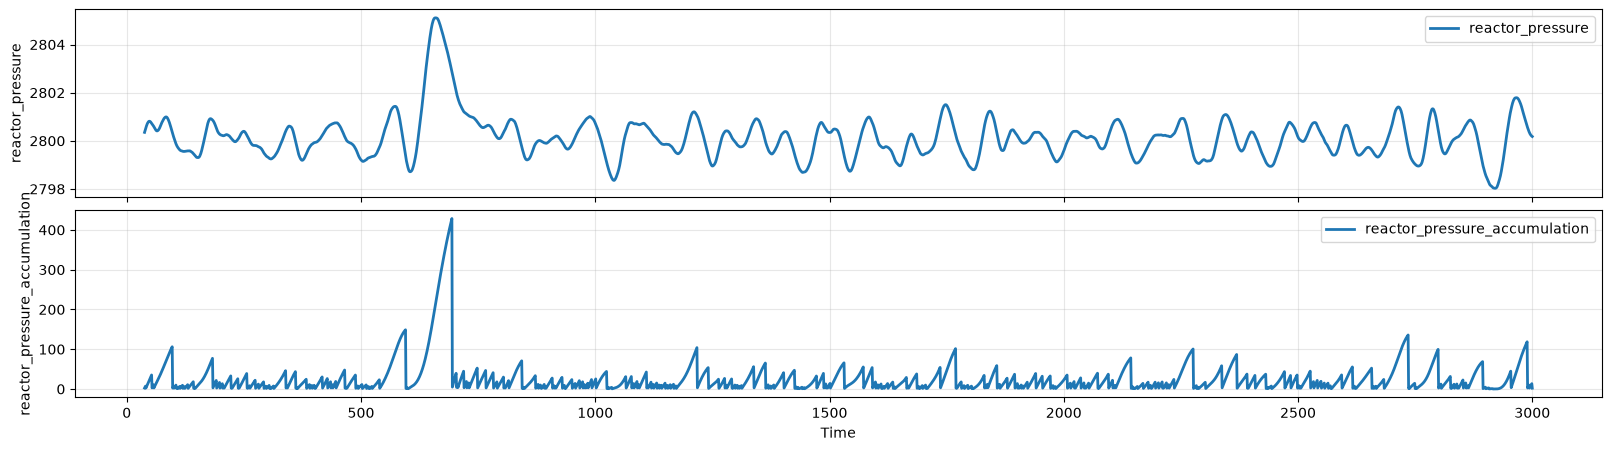

In [ ]:
fg.plot(df, [['reactor_pressure'],
            ['reactor_pressure_accumulation']])